In [2]:
import numpy as np
import matplotlib.pyplot as plt

from utils.saveFig import img_save
from config.tf_config import G_X_D, G_S_D, G_S_Sf
from config.matrizes_config import matrizes

In [3]:
A = matrizes['A']

Definição dos polos e dos autovalores da matriz A

In [4]:
polos = np.roots(G_S_Sf["den"])

autovalores = np.linalg.eigvals(A)

Análise de estabilidade (BIBO e Lyapunov)

In [5]:
print("Polos do sistema:", polos)
print("Estável BIBO?", "Sim\n" if np.all(np.real(polos) < 0) else "Não\n")


print("Autovalores da matriz A:", autovalores)
print("Estável de Lyapunov?", "Sim" if np.all(np.real(autovalores) < 0) else "Não")

Polos do sistema: [-0.35  -0.345]
Estável BIBO? Sim

Autovalores da matriz A: [-0.345 -0.35 ]
Estável de Lyapunov? Sim


Definição dos zeros

In [6]:
zerosG1 = np.roots(G_X_D["num"])
zerosG3 = np.roots(G_S_D["num"])
zerosG4 = np.roots(G_S_Sf["num"])

Plot do mapa de polo-zero

Definição dos eixos X e Y

In [7]:
polos_real = np.real(polos)
polos_imag = np.imag(polos)

zeros1_real = np.real(zerosG1)
zeros1_imag = np.imag(zerosG1)

zeros3_real = np.real(zerosG3)
zeros3_imag = np.imag(zerosG3)

zeros4_real = np.real(zerosG4)
zeros4_imag = np.imag(zerosG4)

print(f"Zero G1: {zerosG1}, Zero G3: {zerosG3}, Zero G4: {zerosG4}")

Zero G1: [-0.34998533], Zero G3: [-0.34999413], Zero G4: [0.]


Plot

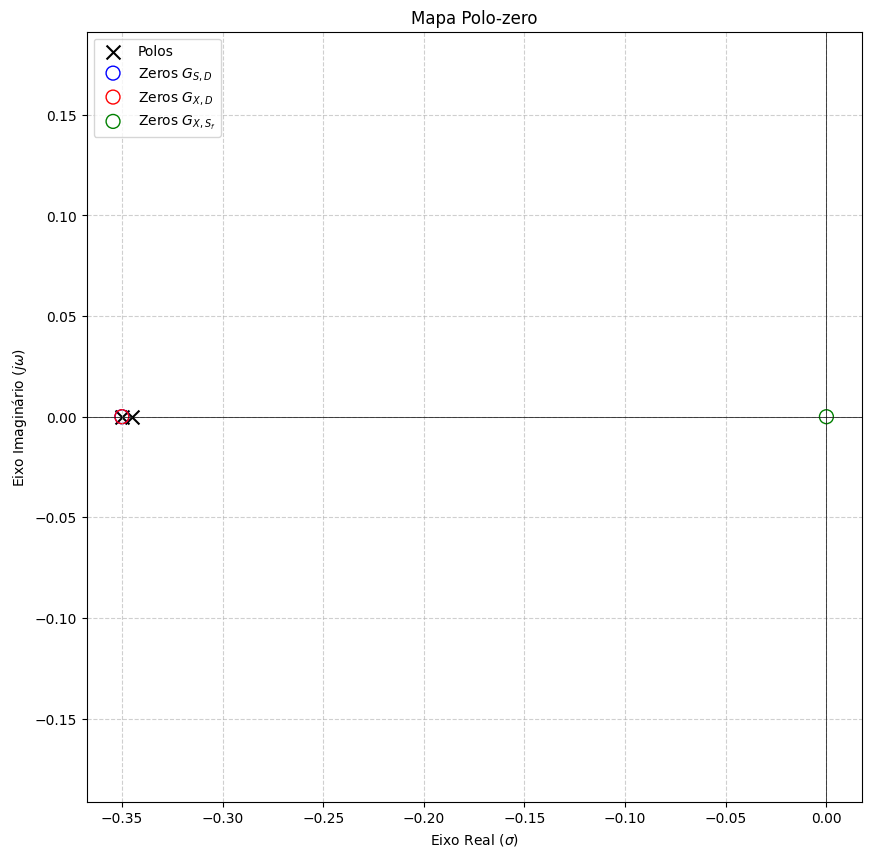

Imagem salva em: c:\Users\rodwa\Desktop\BioReator\BioReator\imgs\MapaPoloZeros\MapaPoloZero.png


In [9]:
# Cria o gráfico
plt.figure(figsize=(10, 10))

# Plota os polos e zeros
plt.scatter(polos_real, polos_imag, marker='x', color='black', s=100, label='Polos')
plt.scatter(zeros1_real, zeros1_imag, marker='o', facecolors='none', edgecolors='blue', s=100, label=r'Zeros $G_{S,D}$')
plt.scatter(zeros3_real, zeros3_imag, marker='o', facecolors='none', edgecolors='red', s=100, label=r'Zeros $G_{X,D}$')
plt.scatter(zeros4_real, zeros4_imag, marker='o', facecolors='none', edgecolors='green', s=100, label=r'Zeros $G_{X,S_f}$')


plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Mapa Polo-zero')
plt.xlabel(r'Eixo Real ($\sigma$)')
plt.ylabel(r'Eixo Imaginário ($j\omega$)')
plt.legend()
plt.axis('equal')

img_save(file_name="MapaPoloZero",dir_name="MapaPoloZeros")